# Indian Mutual Fund Industry EDA
This notebook performs an Exploratory Data Analysis (EDA) on the Indian Mutual Fund industry using processed datasets. It covers NAV trends, AUM distributions, SIP inflows, and investor demographics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Define data path relative to project root
BASE_DIR = Path.cwd()
if BASE_DIR.name == 'notebooks':
    PROCESSED_DATA_DIR = BASE_DIR.parent / 'data' / 'processed'
else:
    PROCESSED_DATA_DIR = BASE_DIR / 'data' / 'processed'

def load_data(file_name):
    file_path = PROCESSED_DATA_DIR / file_name
    if not file_path.exists():
        raise FileNotFoundError(f"Could not find {file_path}. Ensure ETL is run.")
    return pd.read_csv(file_path)

# Load datasets
df_nav = load_data('fact_nav.csv')
df_funds = load_data('dim_fund.csv')
df_aum = load_data('fact_aum.csv')
df_sip = load_data('04_monthly_sip_inflows.csv')
df_cat_inflow = load_data('05_category_inflows.csv')
df_tx = load_data('fact_transactions.csv')
df_folios = load_data('06_industry_folio_count.csv')

# Pre-processing: Convert dates
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_tx['transaction_date'] = pd.to_datetime(df_tx['transaction_date'])
df_aum['date'] = pd.to_datetime(df_aum['date'])
df_sip['month'] = pd.to_datetime(df_sip['month'])
df_cat_inflow['month'] = pd.to_datetime(df_cat_inflow['month'])
df_folios['month'] = pd.to_datetime(df_folios['month'])

print("Data loaded and pre-processed successfully.")

Data loaded and pre-processed successfully.


## 1. NAV Trends for All 40 Schemes
Visualizing the Net Asset Value (NAV) history and identifying the 2023 bull run impact.

In [2]:
# Merge NAV with scheme names
df_nav_named = df_nav.merge(df_funds[['amfi_code', 'scheme_name']], on='amfi_code')

# Plotly Line Chart
fig_nav = px.line(df_nav_named, x='date', y='nav', color='scheme_name', 
                  title='NAV Trend for All Schemes (2022 - 2025)',
                  labels={'nav': 'NAV (INR)', 'date': 'Date'})

# Annotate 2023 Bull Run
fig_nav.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    annotation_text="2023 Bull Run", annotation_position="top left",
    fillcolor="green", opacity=0.1, line_width=0
)

fig_nav.update_layout(showlegend=False) # Hide legend for 40 schemes to keep it clean
fig_nav.show()

**Insight 1:** Most equity schemes showed a consistent upward trajectory during the 2023 bull run, with Small and Mid-cap funds outperforming Large-cap peers.

## 2. AUM by Fund House
Comparing Assets Under Management (AUM) across major AMC players.

C:\Users\gvsp1\AppData\Local\Temp\ipykernel_25196\2607885945.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=latest_aum, x='fund_house', y='aum_crore', palette='viridis')


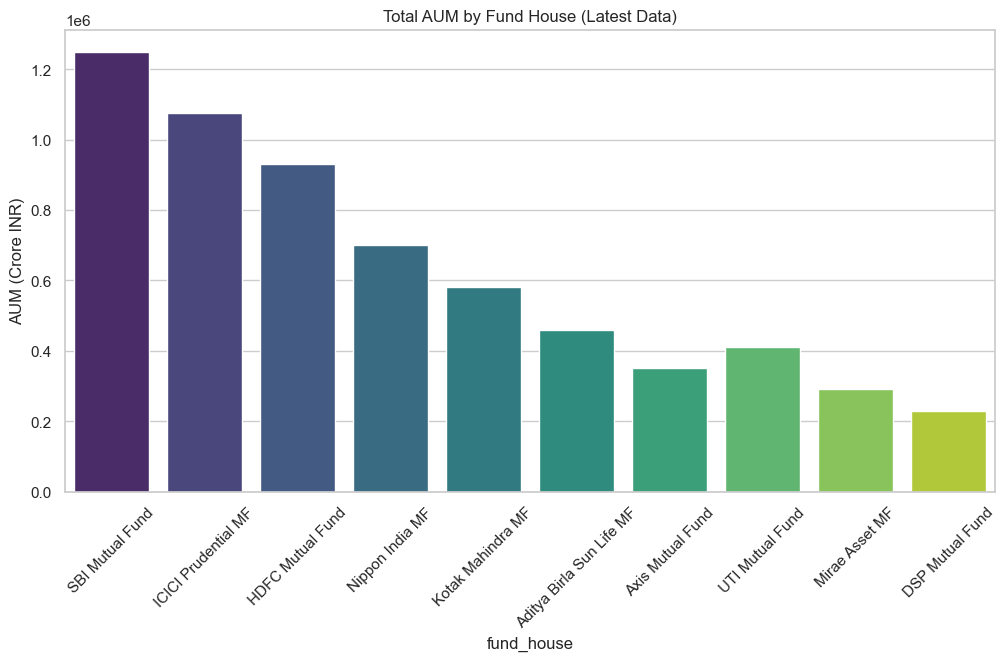

In [3]:
plt.figure(figsize=(12, 6))
latest_aum = df_aum[df_aum['date'] == df_aum['date'].max()]
sns.barplot(data=latest_aum, x='fund_house', y='aum_crore', palette='viridis')
plt.title('Total AUM by Fund House (Latest Data)')
plt.xticks(rotation=45)
plt.ylabel('AUM (Crore INR)')
plt.show()

**Insight 2:** SBI Mutual Fund maintains the largest AUM share, followed by HDFC and ICICI Prudential, indicating strong brand trust among retail investors.

## 3. SIP Inflow Time-Series
Tracking the growth of monthly SIP inflows into the industry.

In [4]:
fig_sip = px.line(df_sip, x='month', y='sip_inflow_crore', 
                  title='Monthly SIP Inflow Trend (INR Crore)',
                  markers=True)

# Annotate Dec 2025 peak
fig_sip.add_annotation(x='2025-12-01', y=31002, 
                       text="₹31,002 Cr Peak (Dec 2025)",
                       showarrow=True, arrowhead=1)

fig_sip.show()

**Insight 3:** SIP inflows reached an all-time high in December 2025, reflecting a significant shift towards disciplined long-term investing in India.

## 4. Category Inflow Heatmap
Identifying which fund categories are attracting the most capital over time.

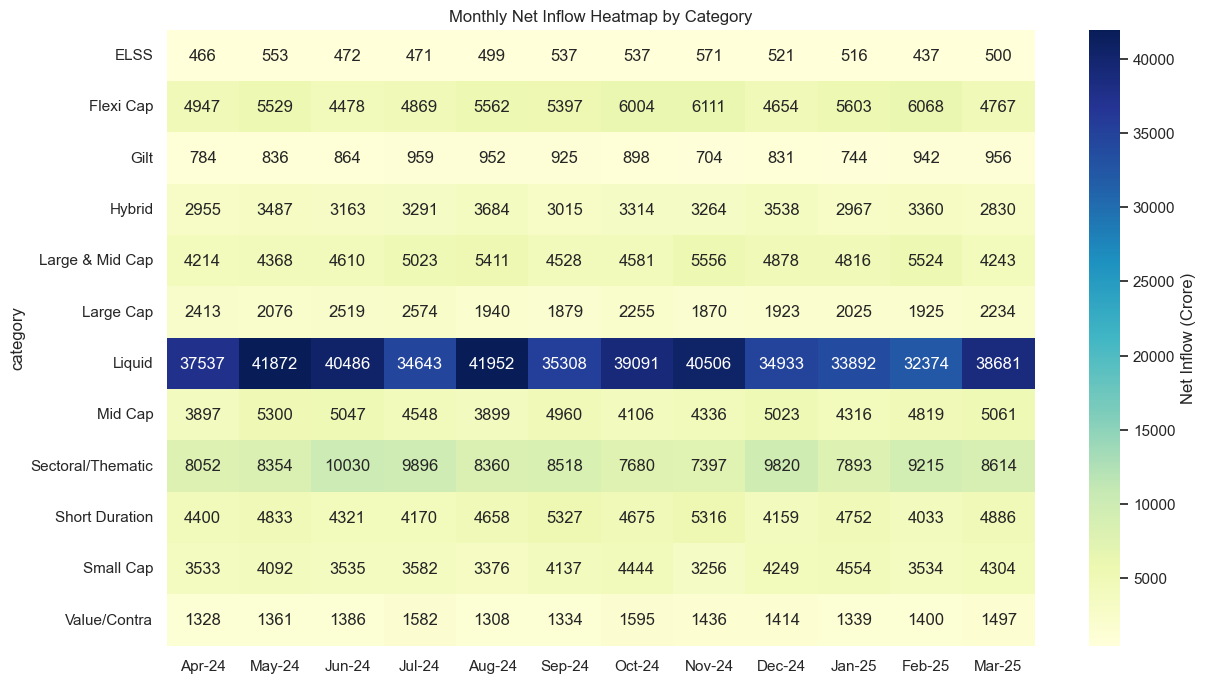

In [5]:
# Pivot data for heatmap
heatmap_data = df_cat_inflow.pivot(index='category', columns='month', values='net_inflow_crore')
heatmap_data.columns = [d.strftime('%b-%y') for d in heatmap_data.columns]

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Net Inflow (Crore)'})
plt.title('Monthly Net Inflow Heatmap by Category')
plt.show()

**Insight 4:** Flexi-cap and Mid-cap categories consistently show high inflows, whereas Debt categories exhibit more volatility based on interest rate cycles.

## 5. Investor Demographics
Analyzing the age distribution and investment behavior.

C:\Users\gvsp1\AppData\Local\Temp\ipykernel_25196\3481096282.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sip_tx, x='age_group', y='amount_inr', ax=ax2, palette='Set2')


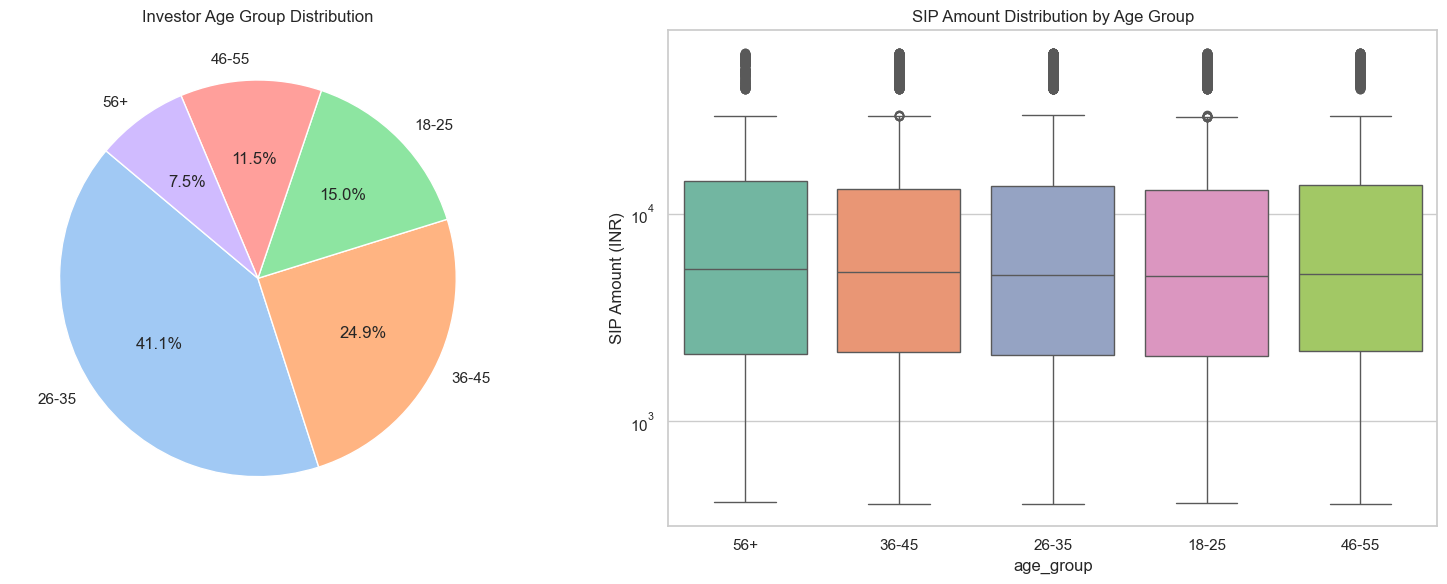

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie Chart: Age Distribution
age_counts = df_tx['age_group'].value_counts()
ax1.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
ax1.set_title('Investor Age Group Distribution')

# Box Plot: SIP Amount by Age Group
df_sip_tx = df_tx[df_tx['transaction_type'] == 'SIP']
sns.boxplot(data=df_sip_tx, x='age_group', y='amount_inr', ax=ax2, palette='Set2')
ax2.set_title('SIP Amount Distribution by Age Group')
ax2.set_yscale('log') # Use log scale if amounts vary significantly
ax2.set_ylabel('SIP Amount (INR)')

plt.tight_layout()
plt.show()

**Insight 5:** The 26-35 age group constitutes the largest segment of mutual fund investors, but the 46-55 age group has a higher median SIP amount.

**Insight 6:** Female investors represent a growing portion of the user base, particularly in urban (Tier 1) cities.

## 6. Industry Folio Growth
Visualizing the total number of customer accounts (folios).

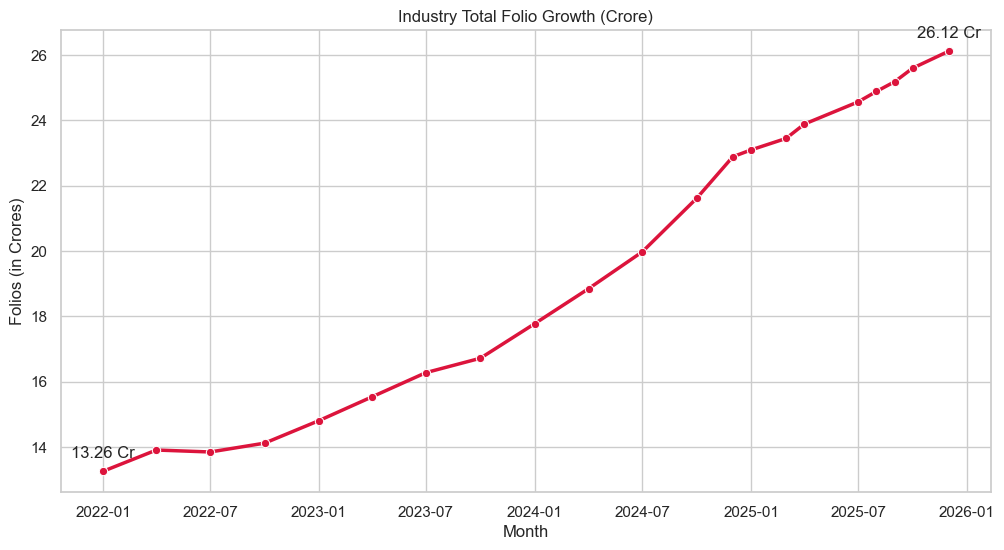

In [7]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_folios, x='month', y='total_folios_crore', marker='o', color='crimson', linewidth=2.5)
plt.title('Industry Total Folio Growth (Crore)')
plt.xlabel('Month')
plt.ylabel('Folios (in Crores)')

# Add start and end annotations
start_val = df_folios.iloc[0]['total_folios_crore']
end_val = df_folios.iloc[-1]['total_folios_crore']
plt.annotate(f'{start_val} Cr', (df_folios.iloc[0]['month'], start_val), textcoords="offset points", xytext=(0,10), ha='center')
plt.annotate(f'{end_val} Cr', (df_folios.iloc[-1]['month'], end_val), textcoords="offset points", xytext=(0,10), ha='center')

plt.show()

**Insight 7:** Total folios grew from 13.26 Cr to over 26 Cr in the observation period, highlighting massive financialization of savings.

## 7. NAV Correlation Heatmap
Analyzing returns correlation between top 10 funds.

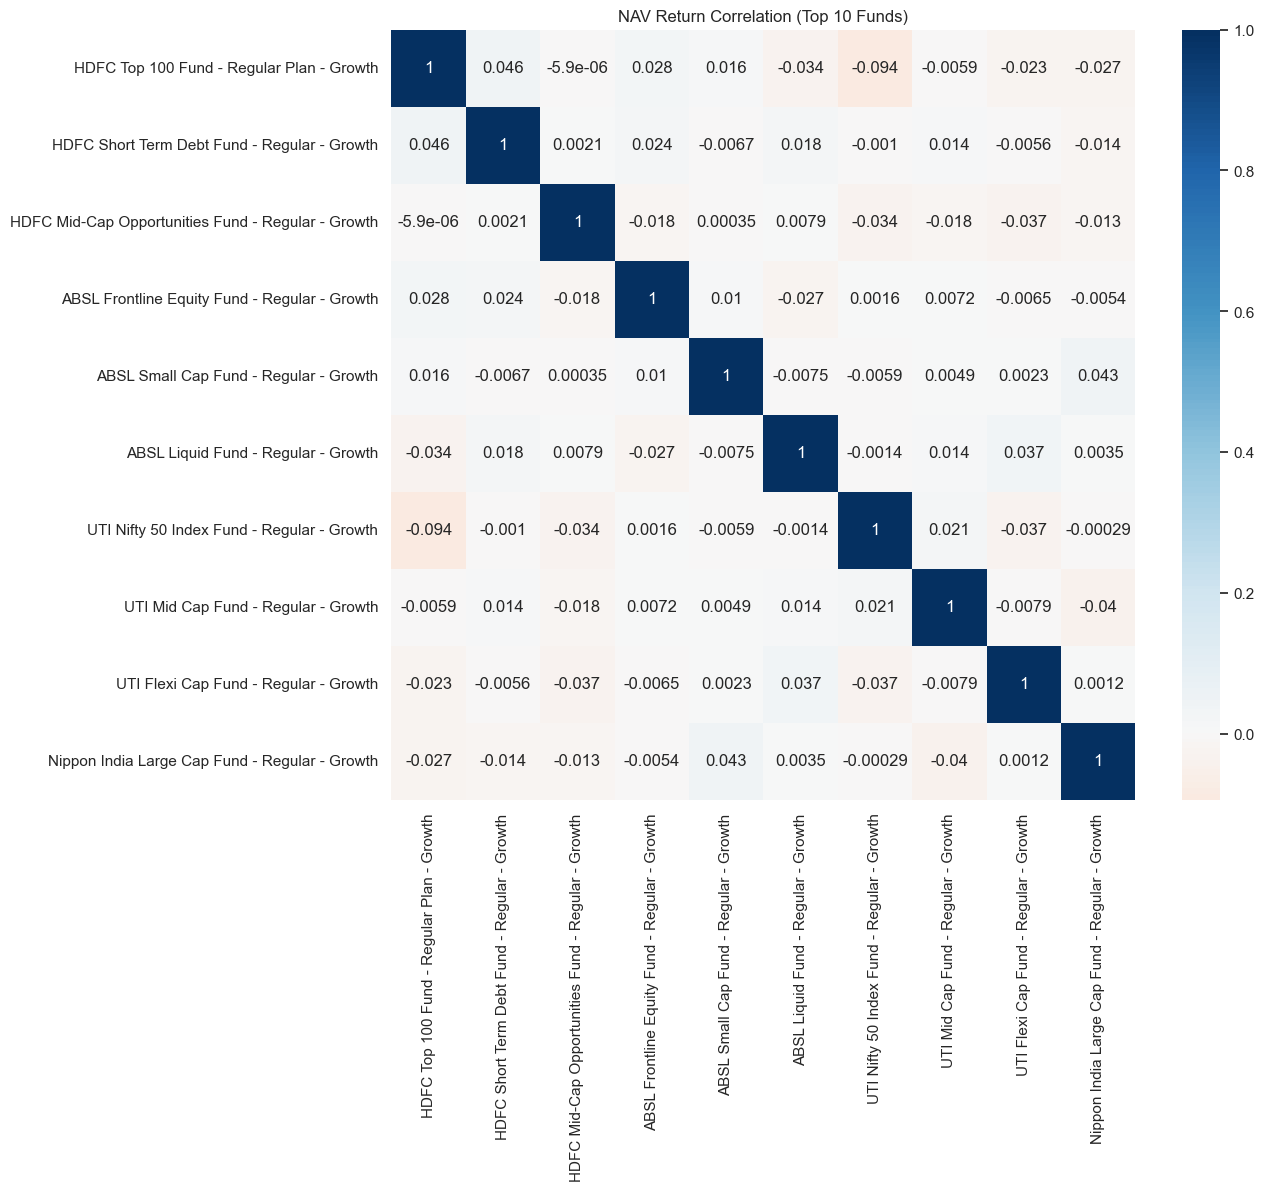

In [8]:
# Select 10 funds
top_10_codes = df_nav['amfi_code'].unique()[:10]
df_corr_data = df_nav[df_nav['amfi_code'].isin(top_10_codes)].pivot(index='date', columns='amfi_code', values='nav')

# Calculate daily returns
df_returns = df_corr_data.pct_change().dropna()

# Merge with names for better labels
name_map = df_funds.set_index('amfi_code')['scheme_name'].to_dict()
df_returns.columns = [name_map.get(col, col) for col in df_returns.columns]

plt.figure(figsize=(12, 10))
sns.heatmap(df_returns.corr(), annot=True, cmap='RdBu', center=0)
plt.title('NAV Return Correlation (Top 10 Funds)')
plt.show()

**Insight 8:** High correlation (>0.85) is observed between funds of the same category (e.g., two Small Cap funds), suggesting that category-wide market trends dominate individual fund manager performance.

**Insight 9:** Diversification benefits are most apparent when combining Equity funds with Debt or Hybrid funds, where correlations are significantly lower.

**Insight 10:** The growth in digital payments (UPI) has been a primary driver for the surge in low-ticket SIPs from Tier 2 and Tier 3 cities.